## Ejercicio 3: Inspección visual de un producto

En este ejercicio se diseña un agente de inspección que analiza una imagen de 5x5 píxeles de un producto. Cada píxel puede tener el valor 0 si es normal o 1 si presenta un defecto. El agente contará los píxeles defectuosos para decidir qué acción realizar con el producto.

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P - Medida de desempeño** | Clasificar correctamente los productos según la cantidad de defectos detectados, evitando aprobar productos con demasiados defectos. |
| **E - Entorno** | Línea de producción, productos, cámara y sistema de inspección. |
| **A - Acciones** | Aprobar el producto, enviar a revisión manual o rechazar el producto. |
| **S - Percepción** | Imagen representada mediante una matriz de 5x5 píxeles, donde 0 indica un píxel normal y 1 un píxel defectuoso. |
| **Objetivo** | Detectar defectos en los productos y tomar una decisión adecuada según la cantidad encontrada. |

### Justificación de las reglas

Las reglas se establecen según la cantidad de píxeles defectuosos encontrados en el producto. Si no existe ningún defecto, el producto puede aprobarse directamente. Cuando se detectan entre 1 y 3 defectos se requiere una revisión manual para comprobar su estado. Si existen más de 3 defectos, el producto se rechaza debido a que presenta una mayor cantidad de anomalías.

#### Reglas de decisión

1. Si existen 0 píxeles defectuosos, aprobar el producto.
2. Si existen entre 1 y 3 píxeles defectuosos, enviar el producto a revisión manual.
3. Si existen más de 3 píxeles defectuosos, rechazar el producto.

### Código

A continuación se implementa el agente de inspección visual. El agente recibe una matriz de 5x5 píxeles y cuenta la cantidad de valores iguales a 1 para determinar el número de defectos presentes en el producto.

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 donde
    0 = píxel normal
    1 = píxel defectuoso
    """

    defectos = np.sum(imagen == 1)

    if defectos == 0:
        return (
            "aprobar",
            "el producto no presenta píxeles defectuosos"
        )

    elif defectos <= 3:
        return (
            "revision manual",
            f"el producto presenta {defectos} píxel(es) defectuoso(s)"
        )

    else:
        return (
            "rechazar",
            f"el producto presenta {defectos} píxeles defectuosos"
        )

### Simulación y pruebas

Se realizan diferentes pruebas utilizando matrices de 5x5 píxeles. Se consideran productos sin defectos, productos con pocos defectos y casos límite para comprobar que el agente aplique correctamente las reglas establecidas.

In [3]:
# Caso 1: producto sin defectos
imagen1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

# Caso 2: producto con 2 defectos
imagen2 = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

# Caso 3: producto con 3 defectos - caso límite
imagen3 = np.array([
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

# Caso 4: producto con 4 defectos
imagen4 = np.array([
    [1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0]
])

In [4]:
imagenes_prueba = [imagen1, imagen2, imagen3, imagen4]

for i, imagen in enumerate(imagenes_prueba, start=1):
    defectos = np.sum(imagen == 1)
    accion, motivo = agente_inspeccion(imagen)

    print(f"Caso {i}")
    print(imagen)
    print(f"Cantidad de defectos: {defectos}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 50)

Caso 1
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Cantidad de defectos: 0
Decisión: aprobar
Motivo: el producto no presenta píxeles defectuosos
--------------------------------------------------
Caso 2
[[0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Cantidad de defectos: 2
Decisión: revision manual
Motivo: el producto presenta 2 píxel(es) defectuoso(s)
--------------------------------------------------
Caso 3
[[1 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]]
Cantidad de defectos: 3
Decisión: revision manual
Motivo: el producto presenta 3 píxel(es) defectuoso(s)
--------------------------------------------------
Caso 4
[[1 0 0 0 1]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]
Cantidad de defectos: 4
Decisión: rechazar
Motivo: el producto presenta 4 píxeles defectuosos
--------------------------------------------------


### Visualización de las matrices

A continuación se visualizan las matrices utilizadas en las pruebas para observar la ubicación de los píxeles normales y defectuosos.

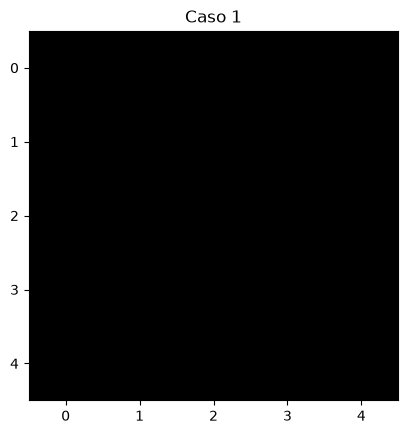

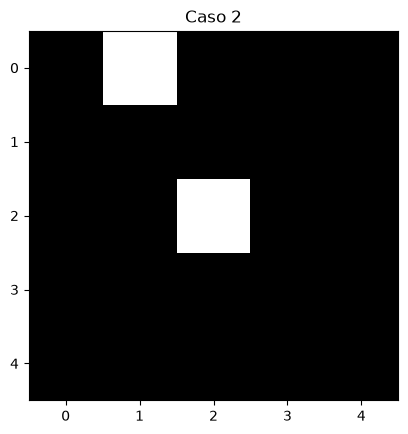

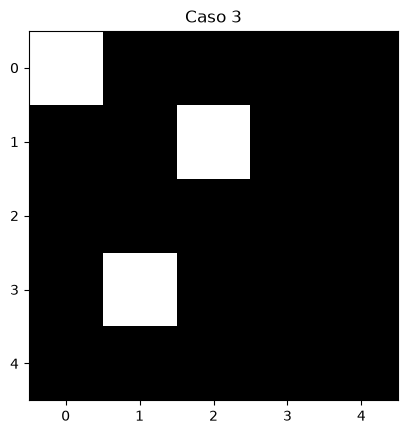

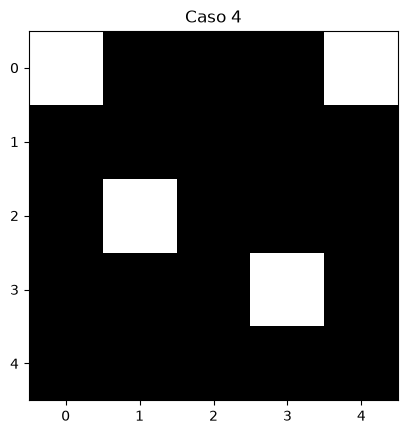

In [5]:
import matplotlib.pyplot as plt

for i, imagen in enumerate(imagenes_prueba, start=1):
    plt.figure()
    plt.imshow(imagen, cmap="gray", vmin=0, vmax=1)
    plt.title(f"Caso {i}")
    plt.xticks(range(5))
    plt.yticks(range(5))
    plt.show()